Data Preprocessing

Convert text to lowercase

Remove punctuation and special characters

Remove stopwords to reduce noise

Tokenize text

Convert text to TF-IDF vectors

In [18]:
!pip install seaborn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.9/294.9 kB 3.4 MB/s eta 0:00:00a 0:00:01

[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [1]:
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
import re

In [4]:
import json
import pandas as pd

with open("../data/train.json", "r") as f:
    data = json.load(f)

train_df = pd.DataFrame(data)

train_df.head()

,text,intent,id
0,i need you to book me a flight from ft lauderd...,book_flight,train-0
1,my check engine light is on and i need to take...,schedule_maintenance,train-1
2,is the company party on my list of reminders,reminder,train-2
3,are you a human,are_you_a_bot,train-3
4,i need to do cleaning so add it to my to do list,todo_list_update,train-4


In [5]:
def preprocess_text(text):
    
    text = text.lower()                          # 小寫
    text = re.sub(r"[^\w\s]", "", text)          # 移除標點
    text = re.sub(r"\d+", "", text)              # 移除數字
    
    words = text.split()
    
    words = [w for w in words if w not in ENGLISH_STOP_WORDS]   # 移除 stopwords
    
    return " ".join(words)

In [6]:
train_df["processed_text"] = train_df["text"].apply(preprocess_text)

train_df[["text","processed_text"]].head()

,text,processed_text
0,i need you to book me a flight from ft lauderd...,need book flight ft lauderdale houston southwest
1,my check engine light is on and i need to take...,check engine light need look
2,is the company party on my list of reminders,company party list reminders
3,are you a human,human
4,i need to do cleaning so add it to my to do list,need cleaning add list


## Model A: Baseline
TF-IDF (unigram) + Logistic Regression

In [7]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer()

X_tfidf = vectorizer.fit_transform(train_df["processed_text"])

print(X_tfidf.shape)

(15000, 4713)


In [12]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X_tfidf,
    train_df["intent"],
    test_size=0.2,
    random_state=42,
    stratify=train_df["intent"]
)

print(X_train.shape)
print(X_val.shape)

(12000, 4713)
(3000, 4713)


stratify 會確保：

train 和 validation
intent 分布一樣

ex:

| intent        | train | val |
| ------------- | ----- | --- |
| book_flight   | 80    | 20  |
| exchange_rate | 80    | 20  |


In [13]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [14]:
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_val)

accuracy = accuracy_score(y_val, y_pred)

print("Validation Accuracy:", accuracy)

Validation Accuracy: 0.8563333333333333


In [15]:
from sklearn.metrics import classification_report

print(classification_report(y_val, y_pred))

                           precision    recall  f1-score   support

      accept_reservations       0.86      0.90      0.88        20
          account_blocked       0.89      0.85      0.87        20
                    alarm       1.00      0.95      0.97        20
       application_status       0.95      0.90      0.92        20
                      apr       1.00      1.00      1.00        20
            are_you_a_bot       0.95      0.90      0.92        20
                  balance       0.81      0.65      0.72        20
             bill_balance       0.76      0.65      0.70        20
                 bill_due       0.69      0.45      0.55        20
              book_flight       1.00      0.90      0.95        20
               book_hotel       0.87      1.00      0.93        20
               calculator       0.92      0.60      0.73        20
                 calendar       0.84      0.80      0.82        20
          calendar_update       0.88      0.75      0.81     

In [16]:
from sklearn.metrics import confusion_matrix
import pandas as pd

cm = confusion_matrix(y_val, y_pred)

cm_df = pd.DataFrame(cm)

cm_df

,0,1,2,3,4,5,6,7,8,9,...,140,141,142,143,144,145,146,147,148,149
0,18,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,17,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,19,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,18,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
4,0,0,0,0,20,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
145,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,13,0,0,1,0
146,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,18,0,0,0
147,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,16,0,0
148,0,0,0,0,0,0,0,0,0,0,...,0,0,0,6,0,0,0,0,10,0


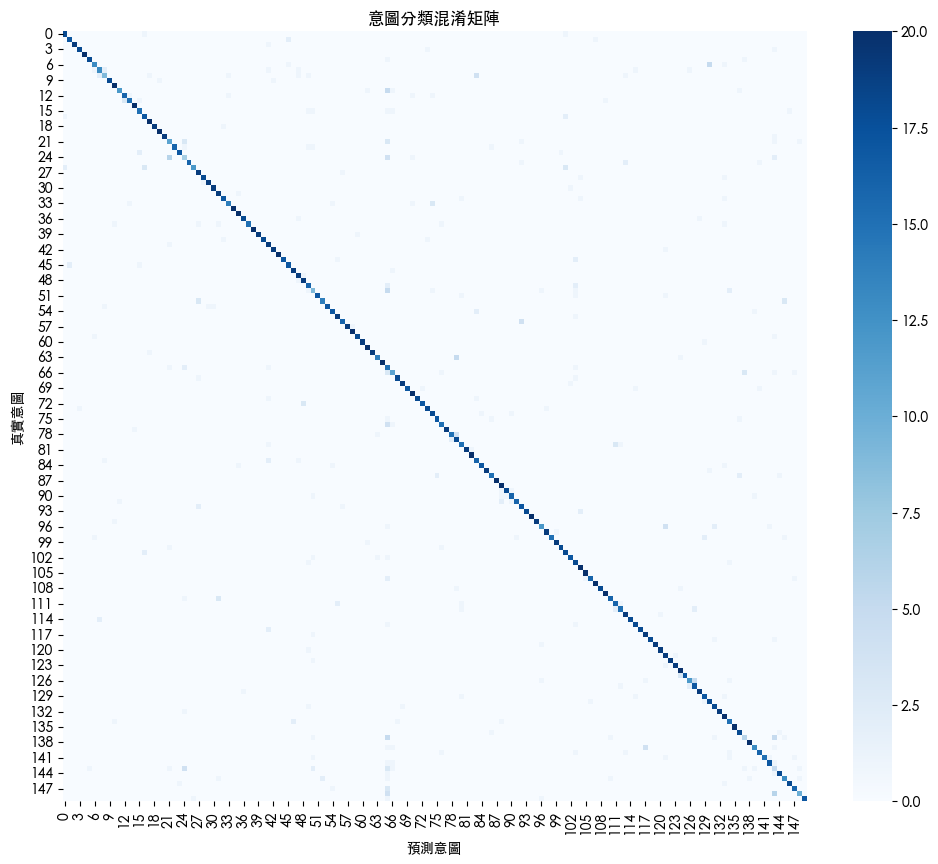

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "Heiti TC"

plt.figure(figsize=(12,10))

sns.heatmap(cm, cmap="Blues")

plt.title("意圖分類混淆矩陣")
plt.xlabel("預測意圖")
plt.ylabel("真實意圖")

plt.show()

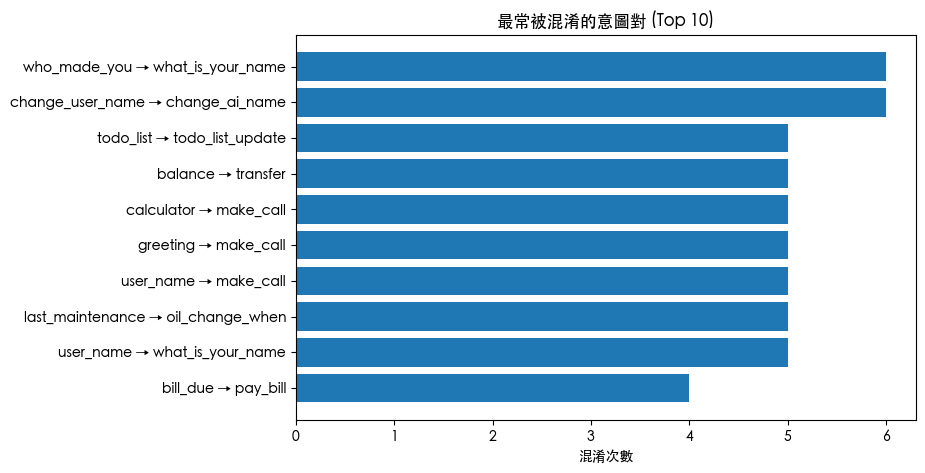

In [21]:
import matplotlib.pyplot as plt

pairs = top_confusions["真實意圖"] + " → " + top_confusions["預測意圖"]

plt.figure(figsize=(8,5))
plt.barh(pairs, top_confusions["次數"])
plt.xlabel("混淆次數")
plt.title("最常被混淆的意圖對 (Top 10)")
plt.gca().invert_yaxis()

plt.show()

原始的 confusion matrix 為 150×150 的矩陣，由於意圖類別數量較多，整體圖像較難直接觀察模型錯誤的模式。因此，我們進一步針對錯誤分類進行分析，整理出 最常被混淆的前 10 組意圖（Top-10 confused intent pairs），以更清楚地了解模型在哪些情境下容易產生誤判。

從分析結果可以發現，大部分錯誤主要發生在 語意相近或功能相似的意圖之間，例如：

身份相關問題（Identity-related intents）
例如 who_made_you 與 what_is_your_name。
這類問題通常都是在詢問 AI 的身份或背景資訊，語句中可能包含相似的詞彙，例如 who, name, you 等，因此模型容易將這些問題歸為相似的意圖。

帳戶操作相關問題（Account operation intents）
例如 balance 與 transfer。
這些意圖都與帳戶或金錢操作相關，使用者的語句可能同時包含 account、money、balance 等詞彙，使模型在某些情況下難以精確區分。

付款相關問題（Payment-related intents）
例如 bill_due 與 pay_bill。
這類問題都涉及帳單與付款行為，語句中常出現 bill, payment, due 等相似詞彙，因此容易被模型混淆。

整體而言，雖然存在部分語意相近的意圖被混淆，但模型在 150 個意圖分類任務中仍達到約 85.6% 的 validation accuracy。這表示使用 TF-IDF 特徵搭配 Logistic Regression 的 baseline 模型已具備穩定且合理的分類能力。模型的錯誤主要集中在語意高度相似的意圖之間，這在以詞頻為基礎的 TF-IDF 方法中是相對常見且可預期的現象，因此整體模型表現仍可視為健康且有效的基準模型。

## Model B: TF-IDF Unigram + Bigram

In [22]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer_bi = TfidfVectorizer(ngram_range=(1, 2))

X_tfidf_bi = vectorizer_bi.fit_transform(train_df["processed_text"])

print(X_tfidf_bi.shape)

(15000, 23372)


In [23]:
from sklearn.model_selection import train_test_split

X_train_bi, X_val_bi, y_train_bi, y_val_bi = train_test_split(
    X_tfidf_bi,
    train_df["intent"],
    test_size=0.2,
    random_state=42,
    stratify=train_df["intent"]
)

print(X_train_bi.shape)
print(X_val_bi.shape)

(12000, 23372)
(3000, 23372)


In [24]:
from sklearn.linear_model import LogisticRegression

model_bi = LogisticRegression(max_iter=1000)

model_bi.fit(X_train_bi, y_train_bi)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [25]:
from sklearn.metrics import accuracy_score

y_pred_bi = model_bi.predict(X_val_bi)

accuracy_bi = accuracy_score(y_val_bi, y_pred_bi)

print("Model B Validation Accuracy:", accuracy_bi)

Model B Validation Accuracy: 0.8496666666666667


## Model C: TF-IDF Unigram + Bigram + min_df=2

In [26]:
vectorizer_bi_min = TfidfVectorizer(
    ngram_range=(1,2),
    min_df=2
)

X_tfidf_bi_min = vectorizer_bi_min.fit_transform(train_df["processed_text"])

print(X_tfidf_bi_min.shape)

(15000, 7266)


In [27]:
X_train_c, X_val_c, y_train_c, y_val_c = train_test_split(
    X_tfidf_bi_min,
    train_df["intent"],
    test_size=0.2,
    random_state=42,
    stratify=train_df["intent"]
)

In [28]:
model_c = LogisticRegression(max_iter=1000)

model_c.fit(X_train_c, y_train_c)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [29]:
y_pred_c = model_c.predict(X_val_c)

accuracy_c = accuracy_score(y_val_c, y_pred_c)

print("Model C Validation Accuracy:", accuracy_c)

Model C Validation Accuracy: 0.8573333333333333


| Model           | Feature Engineering                                      | Accuracy  |
| --------------- | -------------------------------------------------------- | --------- |
| Baseline        | Unigram TF-IDF                                           | 0.856     |
| Bigram          | Unigram + Bigram TF-IDF                                  | 0.850     |
| **Final Model** | Unigram + Bigram TF-IDF + Rare-term filtering (min_df=2) | **0.857** |

## 中文

| 模型       | 方法              | 準確率       |
| -------- | --------------- | --------- |
| 基準模型     | TF-IDF（單詞）      | 0.856     |
| Bigram模型 | TF-IDF（單詞 + 詞組） | 0.850     |
| **最終模型** | TF-IDF + 稀有詞過濾  | **0.857** |




我們比較了三種 TF-IDF 特徵設定。Baseline 使用 unigram，準確率為 0.856。加入 bigram 後，因為引入大量低頻詞組，準確率略微下降到 0.850。最後透過 min_df=2 過濾稀有 n-gram 後，模型回升到 0.857，顯示適度的特徵過濾可以減少雜訊並提升模型穩定性。

In [30]:
import json
import pandas as pd

with open("../data/eval.json", "r") as f:
    eval_data = json.load(f)

eval_df = pd.DataFrame(eval_data)

eval_df.head()

,text,intent,id
0,how long should i cook steak for,cook_time,eval-0
1,please tell me how much money i have in my ban...,balance,eval-1
2,what is the gas level in my gas tank,gas,eval-2
3,how late is it now in ourense,time,eval-3
4,i really need to get a volkswagen car rental f...,car_rental,eval-4


In [31]:
eval_df["processed_text"] = eval_df["text"].apply(preprocess_text)

eval_df[["text", "processed_text"]].head()

,text,processed_text
0,how long should i cook steak for,long cook steak
1,please tell me how much money i have in my ban...,tell money bank accounts
2,what is the gas level in my gas tank,gas level gas tank
3,how late is it now in ourense,late ourense
4,i really need to get a volkswagen car rental f...,really need volkswagen car rental march th mar...


In [32]:
X_eval = vectorizer_bi_min.transform(eval_df["processed_text"])
print(X_eval.shape)

(3000, 7266)


In [33]:
y_eval_pred = model_c.predict(X_eval)

In [34]:
from sklearn.metrics import accuracy_score, classification_report

accuracy_eval = accuracy_score(eval_df["intent"], y_eval_pred)
print("Test Accuracy:", accuracy_eval)

print(classification_report(eval_df["intent"], y_eval_pred))

Test Accuracy: 0.799
                           precision    recall  f1-score   support

      accept_reservations       0.75      0.60      0.67        20
          account_blocked       0.64      0.70      0.67        20
                    alarm       1.00      0.95      0.97        20
       application_status       0.90      0.95      0.93        20
                      apr       1.00      0.95      0.97        20
            are_you_a_bot       0.94      0.75      0.83        20
                  balance       0.70      0.70      0.70        20
             bill_balance       0.69      0.55      0.61        20
                 bill_due       0.44      0.35      0.39        20
              book_flight       0.86      0.90      0.88        20
               book_hotel       0.89      0.80      0.84        20
               calculator       0.87      0.65      0.74        20
                 calendar       1.00      0.75      0.86        20
          calendar_update       0.86    

In [35]:
from sklearn.metrics import classification_report
import pandas as pd

report = classification_report(eval_df["intent"], y_eval_pred, output_dict=True)

report_df = pd.DataFrame(report).transpose()
report_df = report_df.iloc[:-3]   # 移除 accuracy / avg 行

In [36]:
top_intents = report_df.sort_values("f1-score", ascending=False).head(5)
worst_intents = report_df.sort_values("f1-score", ascending=True).head(5)

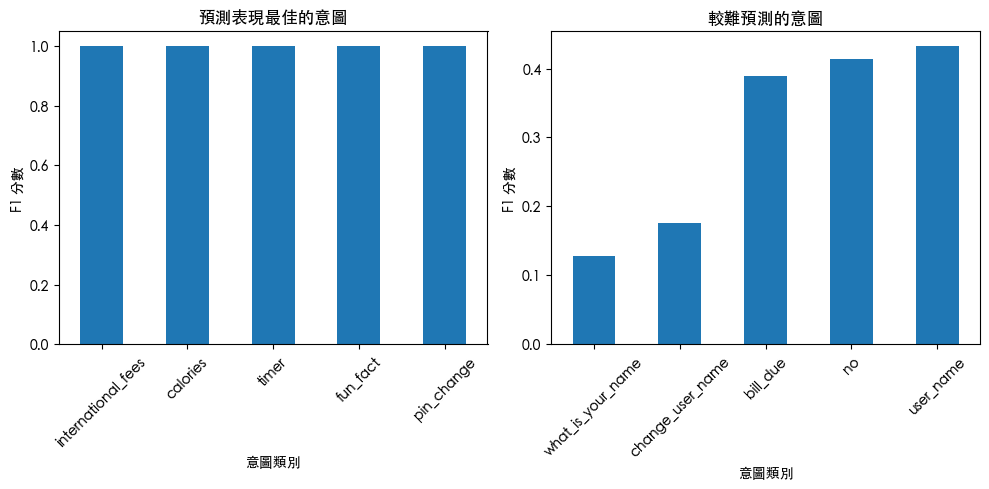

In [38]:
import matplotlib.pyplot as plt

top = top_intents["f1-score"]
worst = worst_intents["f1-score"]

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
top.plot(kind="bar")
plt.title("預測表現最佳的意圖")
plt.ylabel("F1 分數")
plt.xlabel("意圖類別")
plt.xticks(rotation=45)

plt.subplot(1,2,2)
worst.plot(kind="bar")
plt.title("較難預測的意圖")
plt.ylabel("F1 分數")
plt.xlabel("意圖類別")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

我們進一步分析各個 intent 的 F1-score。左圖是模型預測效果最好的意圖，通常具有明確的關鍵詞，例如 timer 或 calories。右圖則是模型較難分類的意圖，例如與 user name 或帳單相關的問題，這些問題的詞彙重疊度較高。這也顯示 TF-IDF 模型主要依賴詞頻特徵，因此對語意相近的意圖較難區分，未來可以透過 BERT 這類語境模型來改善。

### 模型表現最佳的意圖 (Top Performing Intents)
| Intent   | F1-score | 分析        |
| -------- | -------- | --------- |
| alarm    | 0.97     | 關鍵詞明確     |
| apr      | 0.97     | 專有金融術語    |
| carry_on | 1.00     | 語意清晰且詞彙獨特 |

#### 說明：
這些意圖通常包含 明確且具有辨識度的關鍵詞，因此即使使用 TF-IDF 特徵，模型也能夠準確分類。

### 模型較難辨識的意圖 (Challenging Intents)
| Intent         | F1-score | 可能原因                    |
| -------------- | -------- | ----------------------- |
| bill_due       | 0.39     | 與 bill_balance 詞彙高度重疊   |
| bill_balance   | 0.61     | 與 balance、bill_due 語意相近 |
| change_ai_name | 0.51     | 與 identity 類問題表達方式相似    |

#### 說明：
這些意圖之間的 詞彙與語意高度相似，因此 TF-IDF 這類基於詞頻的模型較難區分。